In [35]:
import numpy as np
import open3d
from matplotlib import pyplot as plt

In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
from pycamcal.primitives.rotation import Rotation3D as R3D

## Prepare Scene

In [38]:
from pycamcal.simulation.cornell_box import create_cornell_box
from pycamcal.simulation.checkerboard import create_checkerboard_mesh
from pycamcal.simulation.materials import *
from pycamcal.simulation.mesh_helpers import paint_uniform_material, create_rectangle_mesh

# create basic environment for some nice visual context
cornell_box = create_cornell_box(width=6, height=5)

# create calibration target
checkerboard = create_checkerboard_mesh(num_rows=7, num_cols=10, square_size=0.25)
checkerboard.translate(-checkerboard.get_center())
checkerboard.translate([0, 1, 1])
checkerboard.rotate(R3D.from_euler("x", [90], degrees=True).as_matrix())

# create more visual interest
ball = open3d.geometry.TriangleMesh.create_sphere(radius=0.2)
paint_uniform_material(ball, MAT_MAGENTA)
ball.translate([0, 0, 1])

# create a mirror on the right wall
mirror = create_rectangle_mesh(width=3, length=2)
# paint_uniform_material(mirror, MAT_MIRROR)
paint_uniform_material(mirror, MAT_YELLOW)
mirror.rotate(R3D.from_euler("xy", [90, 90], degrees=True).as_matrix())
mirror.translate([2.9, 0, 2])

scene = [*cornell_box.values(), checkerboard, ball, mirror]
print(scene)

[TriangleMesh with 8 points and 2 triangles., TriangleMesh with 8 points and 2 triangles., TriangleMesh with 8 points and 2 triangles., TriangleMesh with 8 points and 2 triangles., TriangleMesh with 8 points and 2 triangles., TriangleMesh with 280 points and 140 triangles., TriangleMesh with 762 points and 1520 triangles., TriangleMesh with 4 points and 2 triangles.]


In [ ]:
# preview scene geometry
if False:
    open3d.visualization.draw_geometries(scene, mesh_show_back_face=True)

## Prepare Camera

In [40]:
from pycamcal.camera_model import CameraModel
from pycamcal.camera_model import RadialTangentialDistortion

distortion = RadialTangentialDistortion(
    k1=-0.25,
    k2=+0.05,
    k3=0.0,
    p1=0.0,
    p2=0.0
)

camera = CameraModel.from_fov(
    res_xy = (1200/2, 1000/2),
    fov_xy = (72, 60),
    # distortion = distortion
    distortion = None
)

print(camera)

if not distortion.is_valid_over_entire_fov(camera.get_fov(degrees=False)):
    print("WARNING: Distortion model is not valid over entire FOV! Certain regions are potentially unreachable and inversion behavior may be undefined.")## Prepare Camera

{'res_xy': [600, 500],
 'fx': Array(412.91458, dtype=float32),
 'fy': Array(433.0127, dtype=float32),
 'cx': 300.0,
 'cy': 250.0,
 'distortion': None}


## Render

[8 8 8 ... 8 8 8]
[8 8 8 ... 8 8 8]
[2 2 2 ... 2 2 2]
[3 3 3 ... 3 3 3]
[4 4 4 ... 4 4 4]
[0 0 0 ... 0 0 0]
[6 6 6 ... 6 6 6]
[5 5 5 ... 5 5 5]
(500, 600, 3)


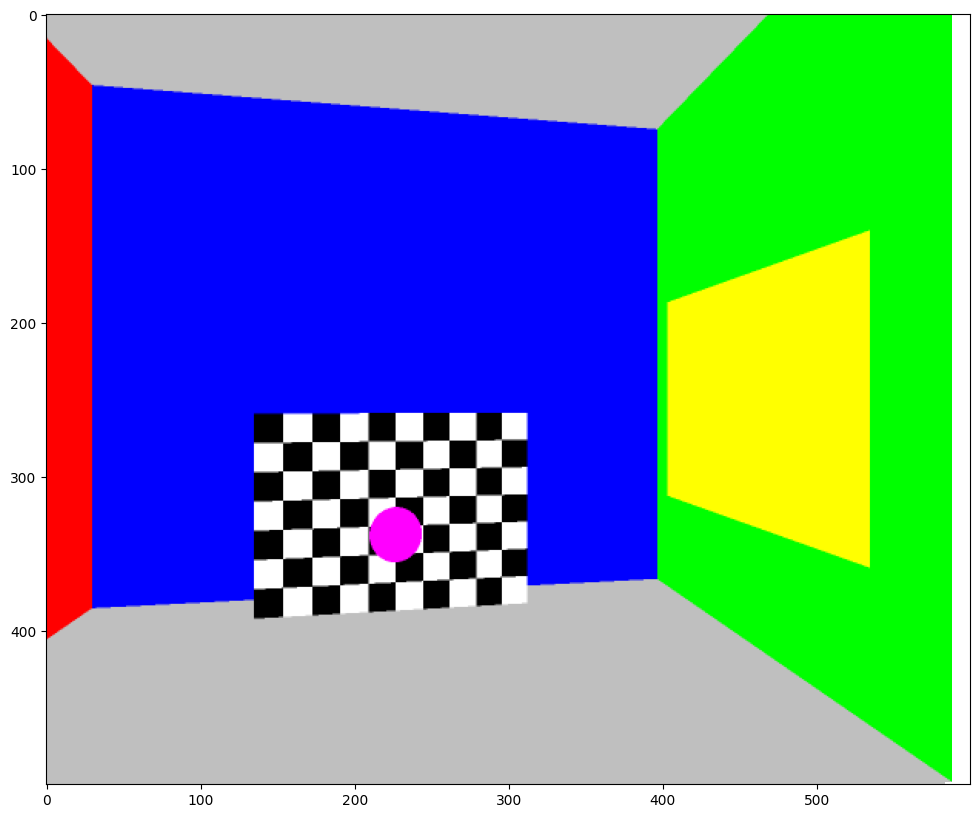

In [41]:
from pycamcal.primitives.pose import Pose3D
from pycamcal.simulation.raycasting import simulate_capture

camera_pose = Pose3D(
    np.array([0, -5.0, 2.0]),
    R3D.from_euler("xy", [-90, 10], degrees=True)
)

image = simulate_capture(scene, camera, camera_pose, rays_per_pixel=4)
print(image.shape)

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(image)